# 01 Data Preparation

FRED 7 系列と S&P500 を取得し、週次 W-FRI に揃えて変換・標準化する。

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# このnotebookと同じディレクトリを sys.path に追加して _helpers を import
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import _helpers as h
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語フォント設定（seaborn の後にロード）

sns.set_theme(style="whitegrid")
japanize_matplotlib.japanize()  # seaborn が font.family を上書きするため、明示的に再設定

## FRED 7 系列を取得

In [2]:
df_raw = h.load_fred_weekly(start=h.DEFAULT_START_DATE)
df_raw.to_parquet(h.FRED_WEEKLY_RAW_PARQUET)
print(f"Shape: {df_raw.shape}")
print(f"Date range: {df_raw.index.min().date()} 〜 {df_raw.index.max().date()}")
df_raw.head()

Shape: (1166, 7)
Date range: 2003-12-05 〜 2026-04-03


,INDPRO,ICSA,T10YIE,CPIAUCSL,STLFSI4,BAA10Y,T10Y2Y
2003-12-05,92.2602,357000.0,2.31,185.5,-0.2727,2.33,2.35
2003-12-12,92.2602,367000.0,2.35,185.5,-0.2475,2.34,2.42
2003-12-19,92.2602,363000.0,2.20,185.5,-0.2529,2.33,2.33
2003-12-26,92.2602,354000.0,2.23,185.5,-0.2354,2.33,2.35
2004-01-02,92.4006,349000.0,2.32,186.3,-0.2785,2.32,2.44


## 生値の可視化

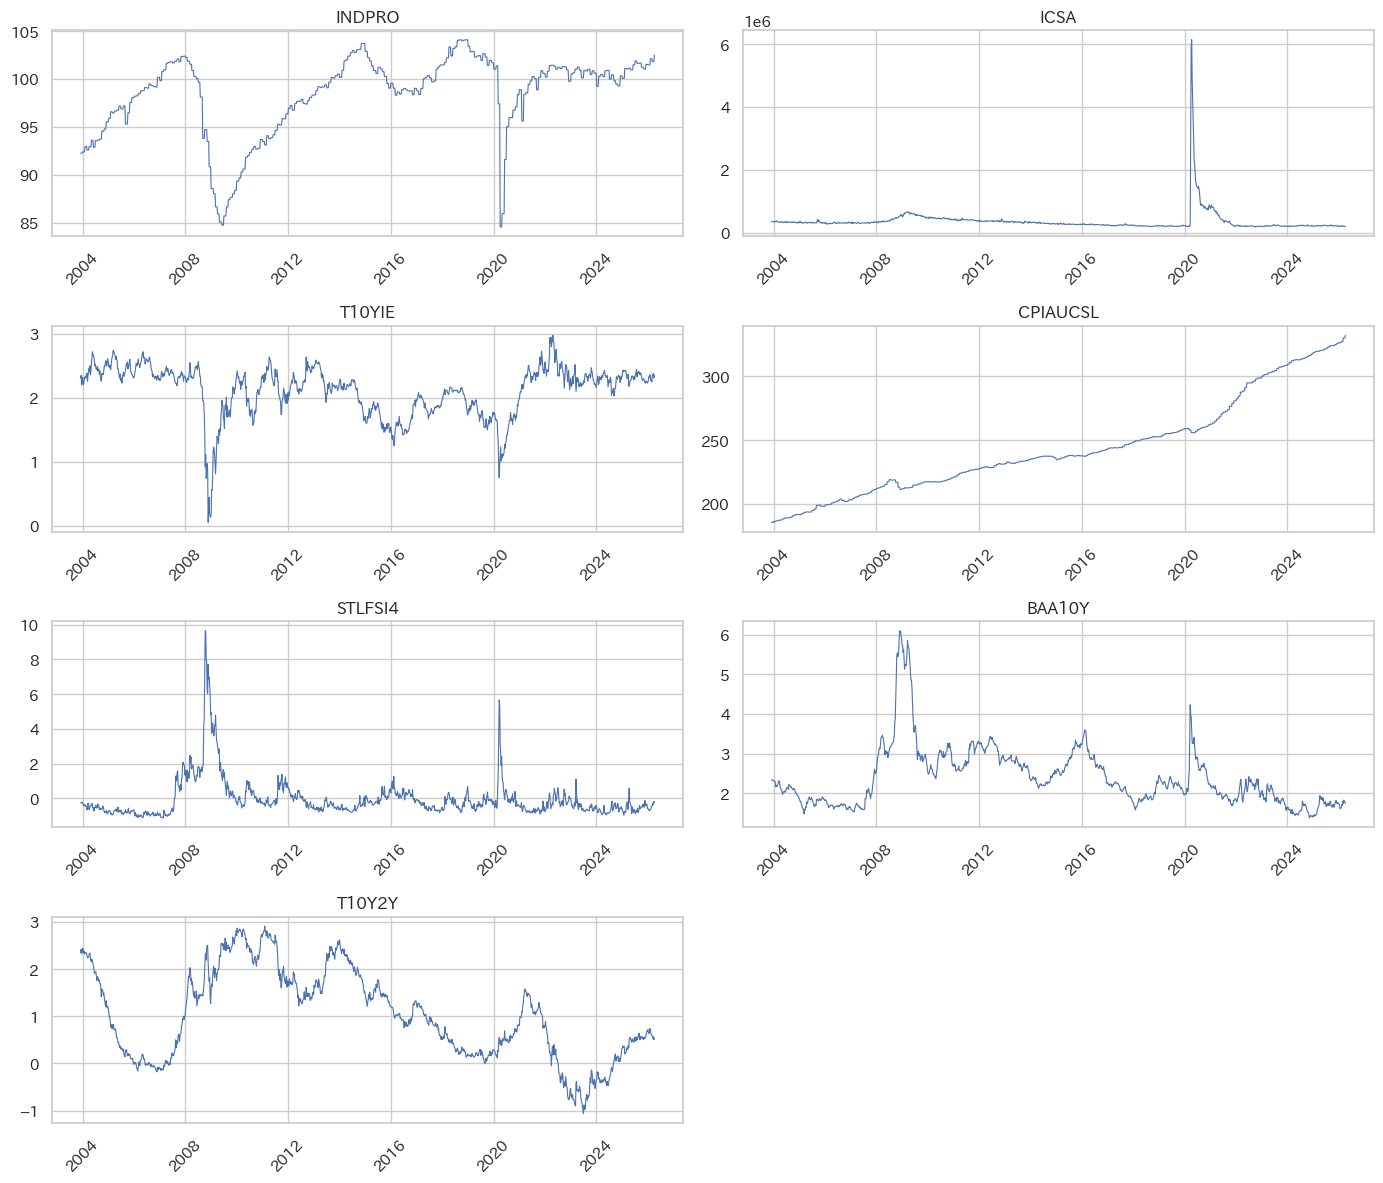

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for ax, col in zip(axes.flatten(), h.FRED_SERIES_IDS):
    ax.plot(df_raw.index, df_raw[col], linewidth=0.8)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
axes.flatten()[-1].axis("off")  # 8番目は空
plt.tight_layout()
plt.show()

## 変換と標準化

In [4]:
features = h.transform_features(df_raw)
features.to_parquet(h.FEATURES_WEEKLY_PARQUET)
print(f"Features shape: {features.shape}")
features.describe().round(3)

Features shape: (1111, 7)


,INDPRO,ICSA,T10YIE,CPIAUCSL,STLFSI4,BAA10Y,T10Y2Y
count,1111.000,1111.000,1111.000,1111.000,1111.000,1111.000,1111.000
mean,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.950,-0.631,-5.108,-2.433,-0.926,-1.321,-2.146
25%,-0.330,-0.187,-0.590,-0.571,-0.527,-0.747,-0.813
50%,0.245,-0.155,0.284,-0.136,-0.265,-0.225,-0.135
75%,0.524,-0.109,0.658,0.403,0.126,0.527,0.754
max,3.562,14.120,2.206,3.424,8.187,4.692,2.056


## 標準化後の可視化

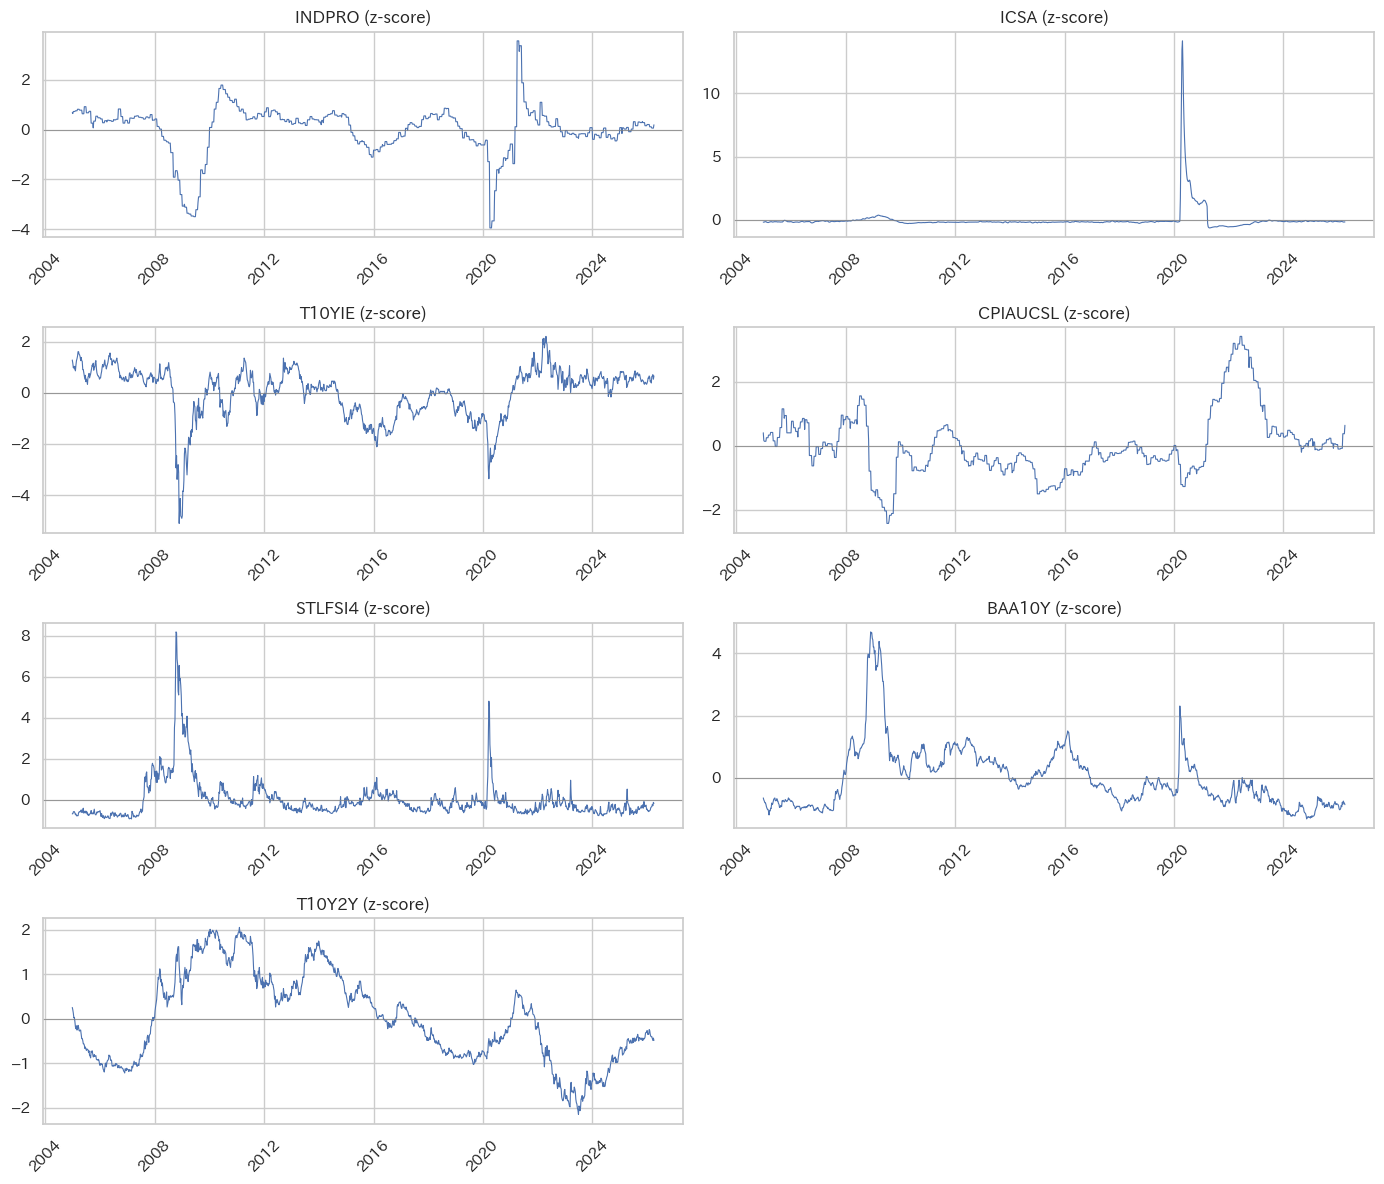

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for ax, col in zip(axes.flatten(), h.FRED_SERIES_IDS):
    ax.plot(features.index, features[col], linewidth=0.8)
    ax.set_title(f"{col} (z-score)")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.tick_params(axis="x", rotation=45)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

## 相関ヒートマップ

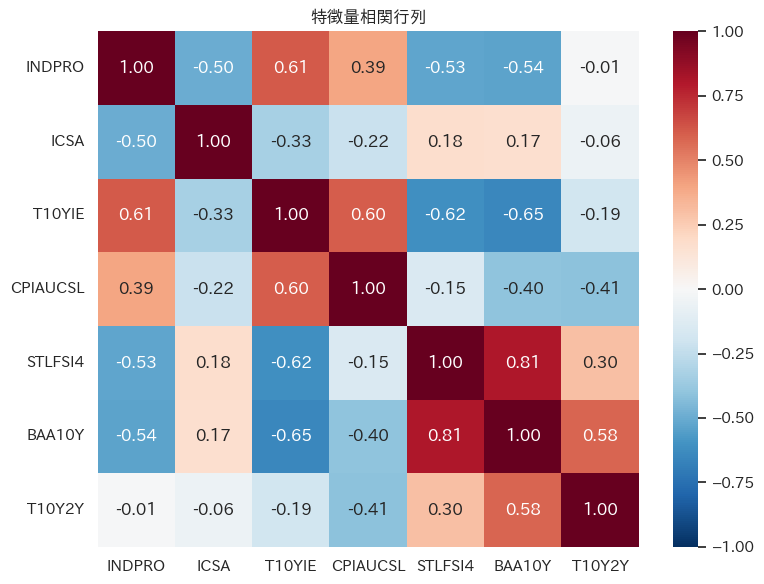

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    features.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
)
ax.set_title("特徴量相関行列")
plt.tight_layout()
plt.show()

## S&P500 週次対数リターン取得

In [7]:
sp500_ret = h.fetch_sp500_weekly_returns(start=h.DEFAULT_START_DATE)
sp500_ret.to_frame().to_parquet(h.SP500_WEEKLY_PARQUET)
print(f"S&P500 returns shape: {sp500_ret.shape}")
print(f"Annualized vol: {sp500_ret.std() * np.sqrt(52):.3%}")
sp500_ret.head()

S&P500 returns shape: (1172,)
Annualized vol: 17.300%


Date
2003-12-12    0.011837
2003-12-19    0.013427
2003-12-26    0.006619
2004-01-02    0.011423
2004-01-09    0.011998
Freq: W-FRI, Name: sp500_logret, dtype: float64

## 出力ファイル確認

In [8]:
for path in [h.FRED_WEEKLY_RAW_PARQUET, h.FEATURES_WEEKLY_PARQUET, h.SP500_WEEKLY_PARQUET]:
    size_kb = path.stat().st_size / 1024
    print(f"{path.name}: {size_kb:.1f} KB")

fred_weekly_raw.parquet: 40.3 KB
features_weekly.parquet: 52.0 KB
sp500_weekly.parquet: 23.6 KB
